# UdaciSense: Optimized Object Recognition
## Notebook 2: Compression Techniques

 
In this notebook, you'll explore different model compression techniques to meet the requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You can experiment with different methods:
1. **Post-training**: Quantization, pruning, graph optimizations.
2. **In-training**: Quantization, pruning, distillation.
Optionally, you can choose to implement other techniques too.

Make sure to experiment with at least two different techniques. 
You will need to combine the selected techniques into a multi-step compression pipeline next, so make sure to select techniques that seem  promising individually but also combined.

### Step 1: Set up the environment

In [2]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [1]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [2]:
!ls 
!ls ../

01_baseline.ipynb	     03_pipeline.ipynb	  mlop_c2_proj_files.tar
02_compression.ipynb	     04_deployment.ipynb  utils
02_compression_backup.ipynb  compression
data  models  proj_root  results


In [3]:
#!cp -pr ../compression .

In [4]:
!ls compression

__init__.py  __pycache__  in_training  post_training


In [5]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from compression.post_training.pruning import prune_model
#from compression.post_training.quantization import quantize_model, QuantizableMobileNetV3_Household
from compression.post_training.quantization import quantize_model, QuantizableMobileNetV3_Household_ptq
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence


from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
#from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household_qat

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP,TARGET_MODEL_COMPRESSION 
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [7]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA A10)']


In [8]:
# Create directories for each technique
compression_types = [
    "post_training/pruning",
    "post_training/quantization",
    "post_training/graph_optimization",
    "in_training/distillation", 
    "in_training/quantization",
    "in_training/pruning",
]
for comp_type in compression_types:
    models_dir = f"../models/{comp_type}"
    models_ckp_dir = f"{models_dir}/checkpoints"
    results_dir = f"../results/{comp_type}"
    
    os.makedirs(models_ckp_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

In [9]:
print(models_ckp_dir, models_dir)
!ls {models_ckp_dir}
!ls {models_dir}

../models/in_training/pruning/checkpoints ../models/in_training/pruning
checkpoints


In [10]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


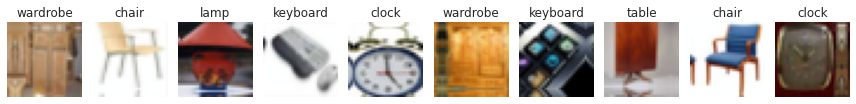


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


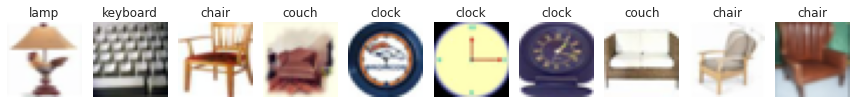

In [11]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

In [12]:
out = next(iter(train_loader))
print(len(out), type(out))
out[0].shape, out[1], out[1].shape

2 <class 'list'>


(torch.Size([128, 3, 32, 32]),
 tensor([1, 3, 8, 5, 5, 2, 4, 8, 0, 7, 0, 7, 8, 4, 0, 0, 0, 3, 9, 9, 8, 3, 6, 3,
         3, 7, 8, 2, 7, 8, 2, 4, 6, 2, 6, 1, 3, 3, 7, 8, 9, 2, 8, 0, 7, 1, 4, 9,
         6, 6, 1, 4, 9, 2, 0, 2, 3, 9, 8, 4, 2, 3, 5, 7, 0, 8, 1, 9, 5, 5, 3, 7,
         7, 1, 0, 3, 3, 8, 6, 1, 1, 8, 8, 9, 3, 7, 9, 4, 8, 3, 7, 0, 9, 1, 6, 1,
         9, 0, 6, 5, 6, 2, 0, 6, 5, 5, 2, 0, 5, 3, 9, 2, 3, 0, 4, 0, 3, 1, 9, 3,
         5, 2, 0, 7, 5, 6, 7, 8]),
 torch.Size([128]))

### Step 3: Load the baseline model and metrics

In [13]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
#baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth", map_location=torch.device('cpu')))

print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate compression techniques

Now you'll implement and evaluate different compression techniques. For each technique that you choose, you'll:
1. Implement the technique
2. Evaluate its impact on model size, inference time, and accuracy
3. Analyze the trade-offs

To choose a technique, simply uncomment the apply_{TECHNIQUE_NAME}_technique() function call in the corresponding technique cell block.

#### 4.1 Post-Training - Quantization

Quantization reduces the precision of weights and activations, converting floating-point values to integers.


In [14]:
import copy
# Define a function to apply quantization and evaluate results
def apply_post_training_quantization(quantization_type, backend, device):
    """
    Apply quantization to a model with given method and backend.
    
    Args:
        quantization_type: Quantization method ("static" or "dynamic")
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        device: Which device to use for model loading, training, and evaluation
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/quantization/{quantization_type}"
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying {quantization_type} quantization with {backend} backend")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()

    print_model_summary(orig_model)
    
    # Apply post-training quantization
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER    
    quantized_model = quantize_model(
        orig_model,
        quantization_type=quantization_type,
        calibration_data_loader=train_loader if quantization_type == "static" else None,
        calibration_num_batches=len(train_loader) if quantization_type == "static" else None,  # Set this to the desired value
        backend=backend,
    )
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    evaluate_optimized_model(
        quantized_model, test_loader, experiment_name, class_names, input_size, device=torch.device('cpu')
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=torch.device('cpu'),
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply post-training quantization
## Find info at https://pytorch.org/docs/stable/quantization.html

## TODO: Experiment with different configurations
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
def run_ptq_quant_exp(qtype, device):
    quantization_type = qtype # One of "dynamic" or "static"
    has_quantized = hasattr(torch.backends, "quantized")
    has_engine = hasattr(torch.backends.quantized, "engine")
    if has_quantized and has_engine:
        try:
            torch.backends.quantized.engine = "fbgemm"
            backend = "fbgemm"
            print(f'backend configured is {backend}')
        except:
            pass
    backend = backend  # One of "fbgemm" or "qnnpack"
    device = device  # Define using torch.device()
    # Optimize and evaluate model
    quantized_model, quantized_comparison_results, experiment_name = apply_post_training_quantization(quantization_type, backend=backend, device=device)
    return quantized_model, quantized_comparison_results, experiment_name

backend configured is fbgemm
Applying dynamic quantization with fbgemm backend
Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
   

Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.29it/s]


Baseline metrics saved at ../results/post_training/quantization/dynamic/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  5.90it/s]


Confusion matrix saved to ../results/post_training/quantization/dynamic/confusion_matrix.png


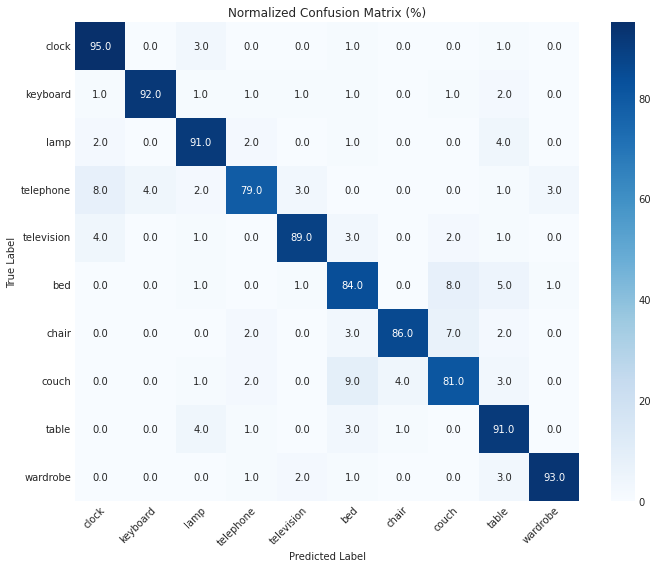


Optimized Model Metrics (post_training/quantization/dynamic):
Accuracy: 88.10%
Model Size: 4.24 MB
CPU Inference Time: 371.21 ms (2.69 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.88it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.65it/s]


Model comparison plot saved to ../results/post_training/quantization/dynamic/comparison.png


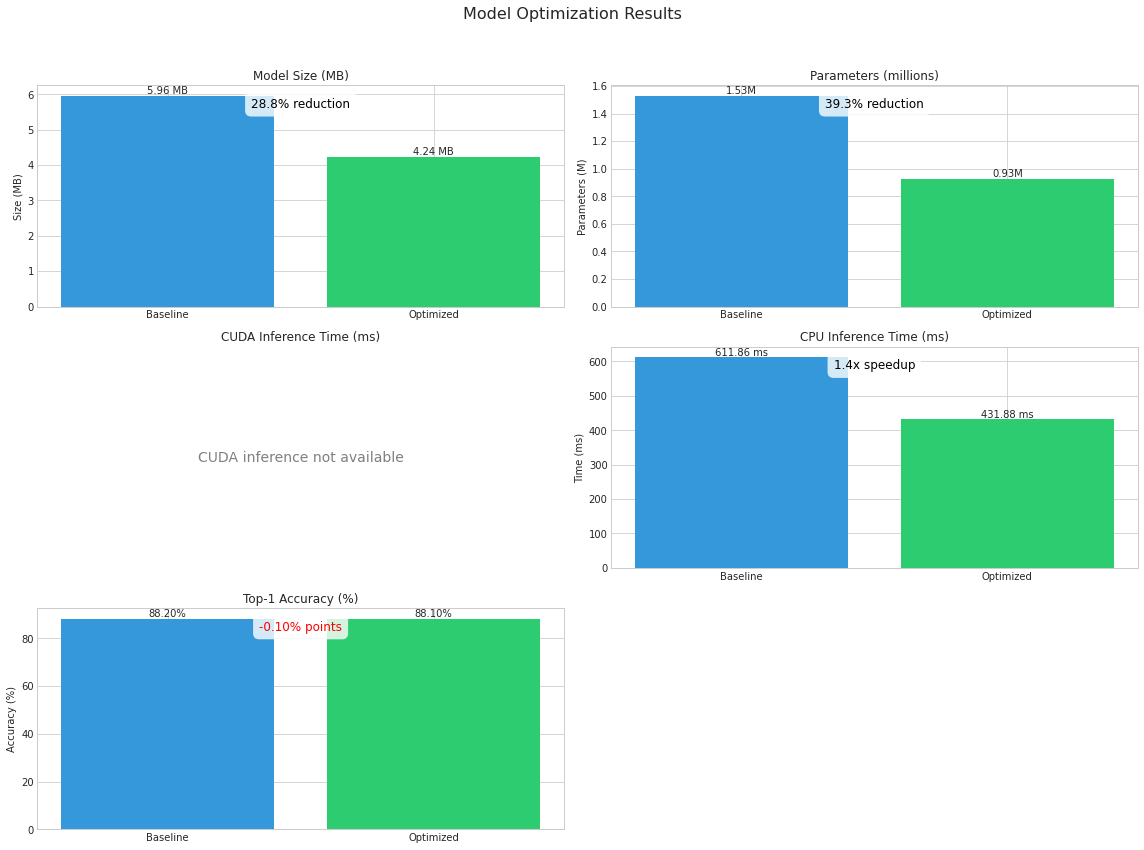


post_training/quantization/dynamic Results:
Model Size: 4.24 MB (28.8% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 431.88 ms (1.4x speedup)
Accuracy: 88.10% (-0.10% change)
Requirements met: False


In [15]:
%reload_ext autoreload
device = 'cpu'
qtype = "dynamic"
quantized_model_dynamic, quantized_comparison_results, experiment_name = run_ptq_quant_exp(qtype, device)

In [16]:
!cat /proc/cpuinfo|grep 'processor'|wc -l

30


#### 4.2 In-training - Quantization

Quantization-aware training simulates quantization during training, allowing the model to adapt to the reduced precision.

In [49]:
%reload_ext autoreload

# Define a function to apply quantization-aware training and evaluate results
def apply_quantization_aware_training(model, config, backend):
    """
    Apply quantization-aware training to a model.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    #qat_start_epoch, num_epochs = config['qat_start_epoch'], config['num_epochs']
    num_epochs = config['num_epochs']
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/quantization/epochs{num_epochs}_start" #{qat_start_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    if config['start_qat']:
        print(f"Applying quantization-aware training with QAT starting at epoch 0 / ending at {num_epochs}")
    else:
        print("Quantization aware training start epoch will be set dynamically once test accuracy > 0.88")
        
    # Move model to specified device
    model = model.to(config['device'])
    
    # Train with QAT
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER   
    quantized_model, qat_stats, qat_best_accuracy, qat_best_epoch = train_model_qat(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"{os.getcwd()}/../models/{experiment_name}/checkpoints",  # Providing full path to manage different sub-directory depths in utility scripts
        backend=backend,
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(qat_stats, f, indent=4)
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        quantized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=qat_stats,
        device=config["device_for_inference"],
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=config["device_for_inference"],
    )
    
    return quantized_model, comparison_results, experiment_name


In [50]:
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

QuantizableMobileNetV3_Household_qat(
  (model): QuantizableMobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): QuantizableInvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU()
          )
          (1): QuantizableSqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): H

Epoch 1/200 [Test]: 100%|██████████| 8/8 [00:02<00:00,  3.07it/s, loss=2.26, acc=21]  


plateau scheduler stepped
Epoch 1/200 - Train Loss: 2.2238, Train Acc: 25.64%, Test Loss: 2.2626, Test Acc: 21.00%, LR: 0.010000, Time: 7.16s
New best quantized model! Saving... (21.00%)
Model saved to /home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start1000/checkpoints


Epoch 2/200 [Test]: 100%|██████████| 8/8 [00:02<00:00,  2.80it/s, loss=2.07, acc=31.6]


plateau scheduler stepped
Epoch 2/200 - Train Loss: 2.0308, Train Acc: 41.04%, Test Loss: 2.0696, Test Acc: 31.60%, LR: 0.010000, Time: 7.32s
New best quantized model! Saving... (31.60%)
Model saved to /home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start1000/checkpoints


...

plateau scheduler stepped
Epoch 200/200 - Train Loss: 0.0154, Train Acc: 99.98%, Test Loss: 0.5333, Test Acc: 87.00%, LR: 0.002824, Time: 7.39s
Training completed. Best accuracy: 88.60%
Best QAT model saved as '/home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start1000/checkpoints' at epoch 151
Converting best QAT model to fully quantized model...
Model saved to ../models/in_training/quantization/epochs200_start1000/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.85it/s]


Baseline metrics saved at ../results/in_training/quantization/epochs200_start1000/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.97it/s]


Confusion matrix saved to ../results/in_training/quantization/epochs200_start1000/confusion_matrix.png


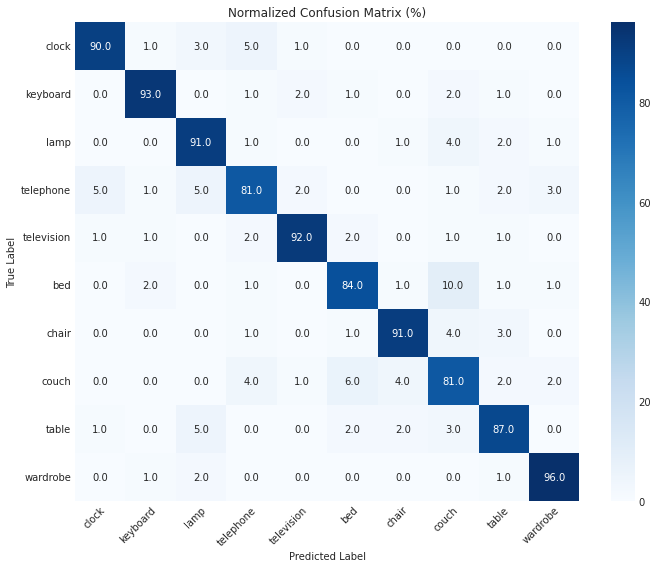

No suitable layers found for weight distribution visualization.
Training history plot saved to ../results/in_training/quantization/epochs200_start1000/training_history.png


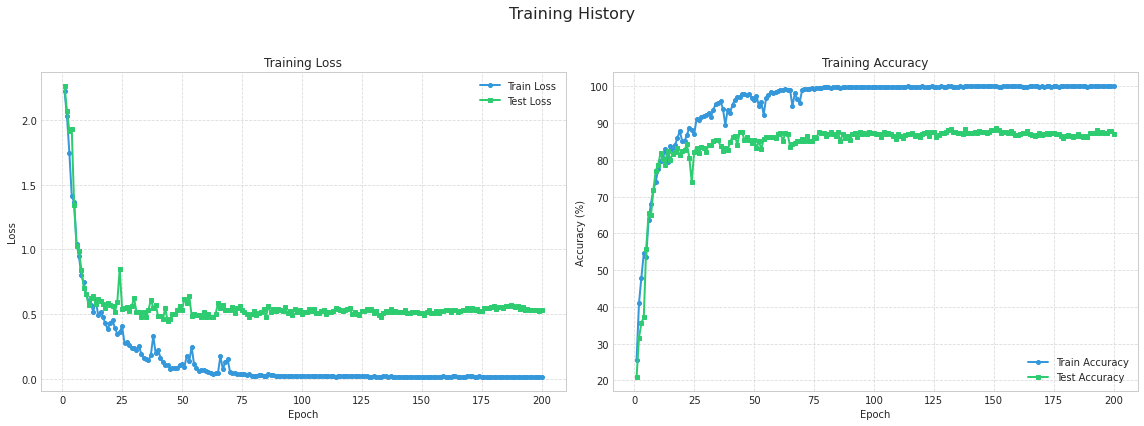


Optimized Model Metrics (in_training/quantization/epochs200_start1000):
Accuracy: 88.60%
Model Size: 1.58 MB
CPU Inference Time: 73.52 ms (13.60 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.66it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.89it/s]


Model comparison plot saved to ../results/in_training/quantization/epochs200_start1000/comparison.png


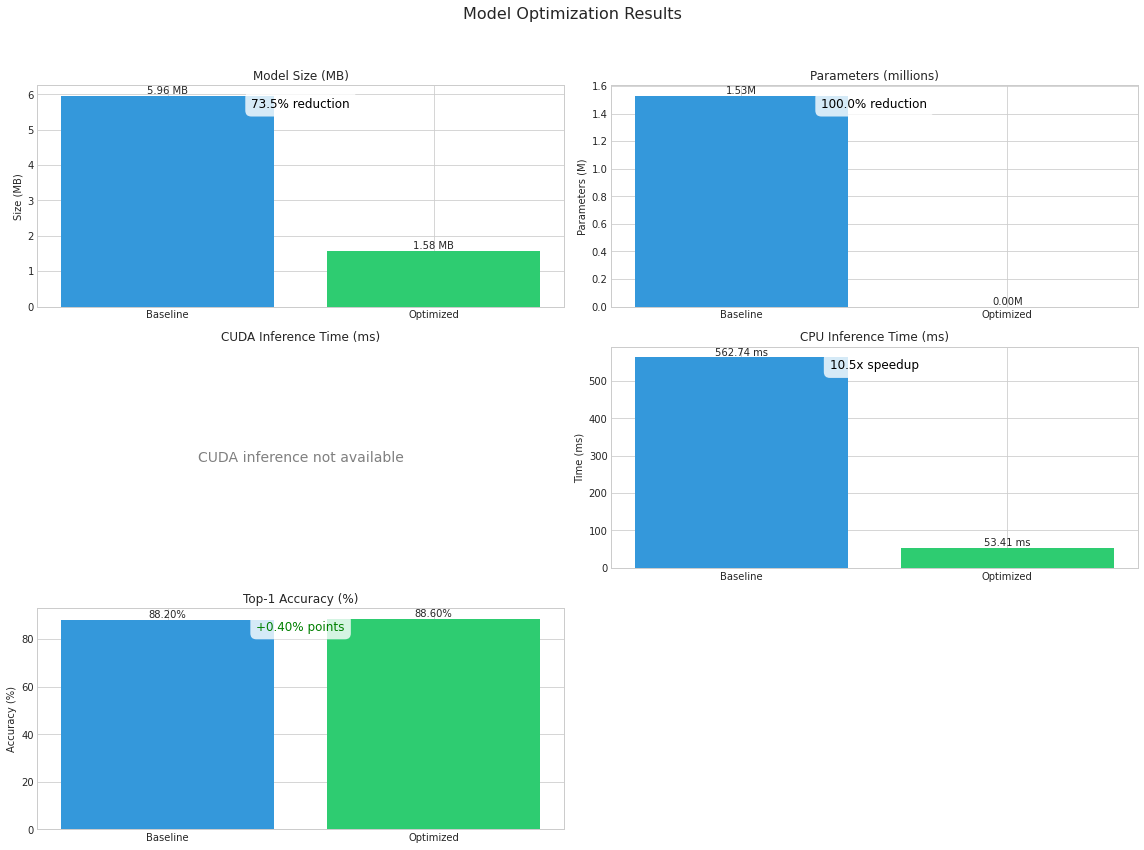


in_training/quantization/epochs200_start1000 Results:
Model Size: 1.58 MB (73.5% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 53.41 ms (10.5x speedup)
Accuracy: 88.60% (+0.40% change)
Requirements met: True


In [47]:
#### Apply quantization-aware training
## Find info at https://pytorch.org/docs/stable/quantization.html
## Create quantizable model version
## TODO: Check the model implementation in the `compression/` folder
torch.cuda.empty_cache()
model = QuantizableMobileNetV3_Household_qat(dropout_rate=0.2, quantize=False)
print(model)

# TODO: Experiment with different configurations
## We recommend testing testing with various start and freeze epochs
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
torch.cuda.empty_cache()
num_epochs = 200

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0001)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',        # 'min' for loss, 'max' for accuracy/metric
    factor=0.9,        # LR is multiplied by this factor
    patience=10,       # Number of epochs with no improvement before reducing LR
    threshold=0.0001,  # Minimum change to qualify as improvement
    cooldown=0,        # Number of epochs to wait before resuming normal operation
    min_lr=1e-6,       # Lower bound for LR
)

config = {
    'freeze_bn_epochs': 3,  # Integer
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': scheduler,  # A PyTorch scheduler
    'patience': 100,  # Integer
    'device': torch.device('cuda'),  # Define with torch.device()
    'device_for_inference': torch.device('cpu'),  # Define with torch.device()
    'grad_clip_norm': None,  # Float
}
backend = "qnnpack"  # One of "fbgemm" or "qnnpack"

qat_model_1, qat_comparison_results_1, experiment_name_1 = apply_quantization_aware_training(model, config, backend)

QuantizableMobileNetV3_Household_qat(
  (model): QuantizableMobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): QuantizableInvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU()
          )
          (1): QuantizableSqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): H

Epoch 1/200 [Test]: 100%|██████████| 8/8 [00:02<00:00,  2.76it/s, loss=2.19, acc=28.3]


plateau scheduler stepped
Epoch 1/200 - Train Loss: 2.2339, Train Acc: 23.38%, Test Loss: 2.1921, Test Acc: 28.30%, LR: 0.010000, Time: 7.32s
New best quantized model! Saving... (28.30%)
Model saved to /home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start/checkpoints


Epoch 2/200 [Test]: 100%|██████████| 8/8 [00:03<00:00,  2.57it/s, loss=2.13, acc=30.1]


plateau scheduler stepped
Epoch 2/200 - Train Loss: 2.0308, Train Acc: 38.94%, Test Loss: 2.1254, Test Acc: 30.10%, LR: 0.010000, Time: 7.60s
New best quantized model! Saving... (30.10%)
Model saved to /home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start/checkpoints


...

plateau scheduler stepped
Epoch 200/200 - Train Loss: 0.0092, Train Acc: 99.98%, Test Loss: 0.5291, Test Acc: 86.40%, LR: 0.003138, Time: 7.42s
Training completed. Best accuracy: 88.00%
Best QAT model saved as '/home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start/checkpoints' at epoch 141
Converting best QAT model to fully quantized model...
Model saved to ../models/in_training/quantization/epochs200_start/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]


Baseline metrics saved at ../results/in_training/quantization/epochs200_start/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.84it/s]


Confusion matrix saved to ../results/in_training/quantization/epochs200_start/confusion_matrix.png


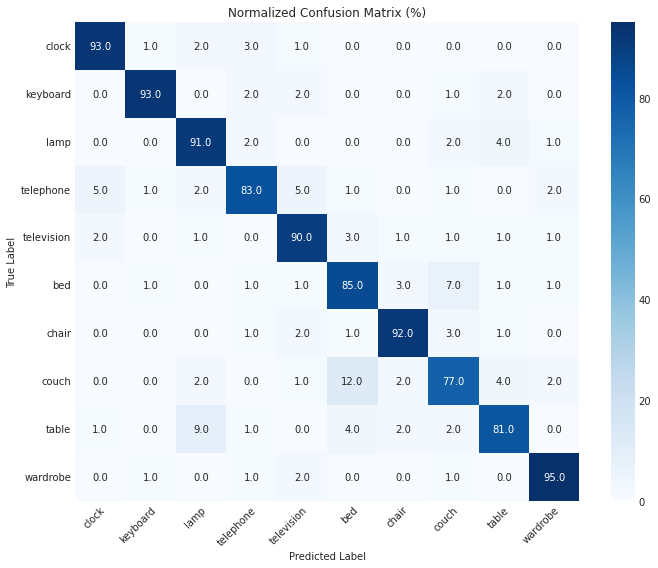

No suitable layers found for weight distribution visualization.
Training history plot saved to ../results/in_training/quantization/epochs200_start/training_history.png


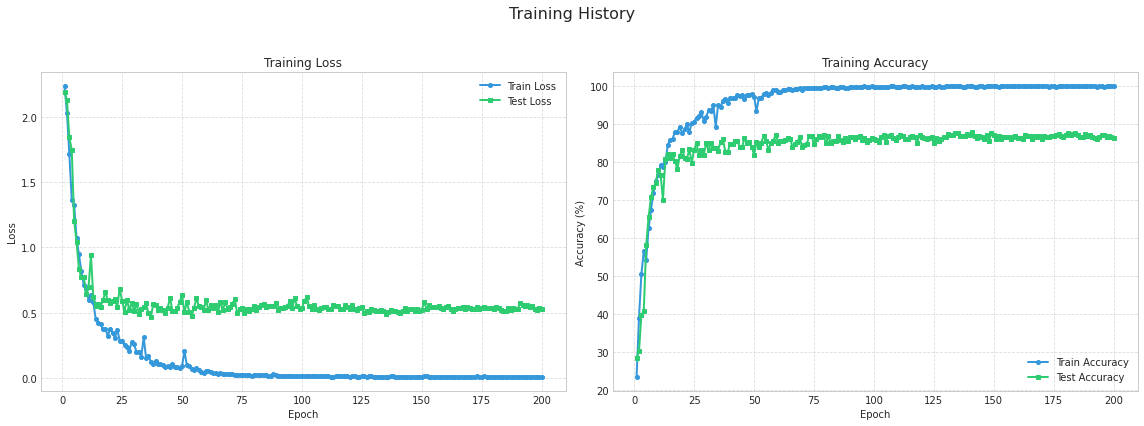


Optimized Model Metrics (in_training/quantization/epochs200_start):
Accuracy: 88.10%
Model Size: 1.58 MB
CPU Inference Time: 66.81 ms (14.97 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.35it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.89it/s]


Model comparison plot saved to ../results/in_training/quantization/epochs200_start/comparison.png


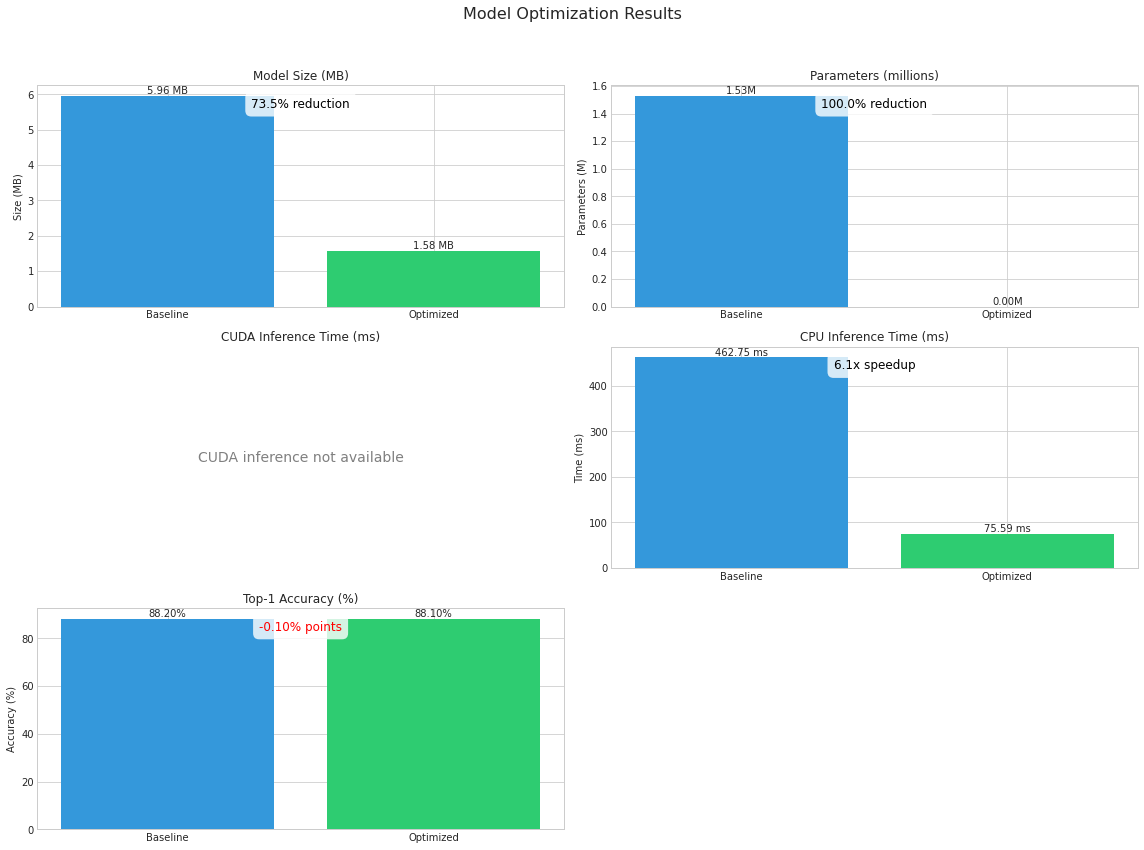


in_training/quantization/epochs200_start Results:
Model Size: 1.58 MB (73.5% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 75.59 ms (6.1x speedup)
Accuracy: 88.10% (-0.10% change)
Requirements met: True


In [52]:
#### Apply quantization-aware training
## Find info at https://pytorch.org/docs/stable/quantization.html
## Create quantizable model version
## TODO: Check the model implementation in the `compression/` folder
torch.cuda.empty_cache()
model = QuantizableMobileNetV3_Household_qat(dropout_rate=0.2, quantize=False)
print(model)

# TODO: Experiment with different configurations
## We recommend testing testing with various start and freeze epochs
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
torch.cuda.empty_cache()
num_epochs = 200

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0001)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',        # 'min' for loss, 'max' for accuracy/metric
    factor=0.9,        # LR is multiplied by this factor
    patience=10,       # Number of epochs with no improvement before reducing LR
    threshold=0.0001,  # Minimum change to qualify as improvement
    cooldown=0,        # Number of epochs to wait before resuming normal operation
    min_lr=1e-6,       # Lower bound for LR
)

config = {
    'start_qat': True, #Boolean
    'freeze_bn_epochs': 3,  # Integer
    'num_epochs': num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': scheduler,  # A PyTorch scheduler
    'patience': 100,  # Integer
    'device': torch.device('cuda'),  # Define with torch.device()
    'device_for_inference': torch.device('cpu'),  # Define with torch.device()
    'grad_clip_norm': None,  # Float
}
backend = "qnnpack"  # One of "fbgemm" or "qnnpack"

qat_model, qat_comparison_results, experiment_name = apply_quantization_aware_training(model, config, backend)

#### 4.3 Post-training - Pruning

Pruning reduces model size by removing weights with small magnitudes that contribute less to the output.

In [53]:
# Define a function to apply pruning and evaluate results
def apply_post_training_pruning(config):
    """
    Apply post-training pruning to a model with given pruning method and amount
    
    Args:
        config: Dictionary containing the configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    amount, pruning_method, device = config['amount'], config['pruning_method'], config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/pruning/{pruning_method}_{amount}_{device}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying post-training pruning with method {pruning_method} and amount {amount:.2f}")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training pruning
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    pruned_model = prune_model(orig_model, pruning_method, amount, config["modules_to_prune"], config["custom_pruning_fn"])
    
    # Save the pruned model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate pruned model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return pruned_model, comparison_results, experiment_name


Applying post-training pruning with method global_unstructured and amount 0.40
Pruning 0 modules with method: global_unstructured, amount: 0.4
Initial model sparsity: 0.00%
debug1
number of modules to be pruned: 54
✅ Model is pruned
Final model sparsity: 39.90%
Model saved to ../models/post_training/pruning/global_unstructured_0-4_cpu/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.50it/s]


Baseline metrics saved at ../results/post_training/pruning/global_unstructured_0-4_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]


Confusion matrix saved to ../results/post_training/pruning/global_unstructured_0-4_cpu/confusion_matrix.png


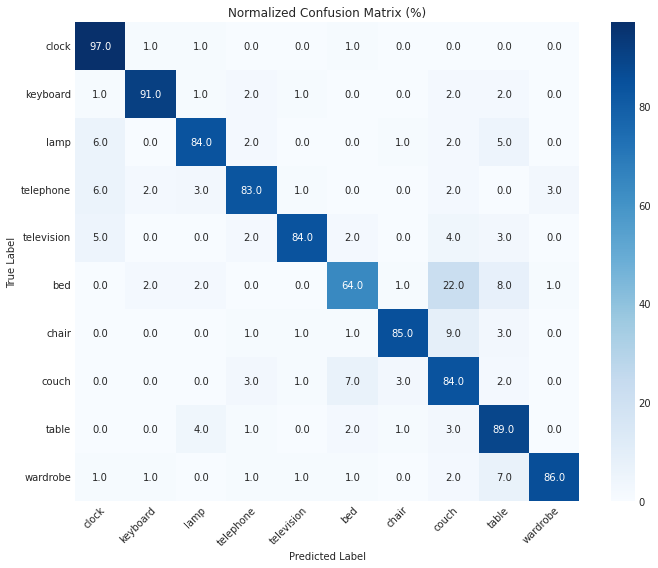


Optimized Model Metrics (post_training/pruning/global_unstructured_0-4_cpu):
Accuracy: 84.70%
Model Size: 5.96 MB
CPU Inference Time: 516.48 ms (1.94 FPS)
CUDA Inference Time: 3.37 ms (297.10 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.57it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.27it/s]


Model comparison plot saved to ../results/post_training/pruning/global_unstructured_0-4_cpu/comparison.png


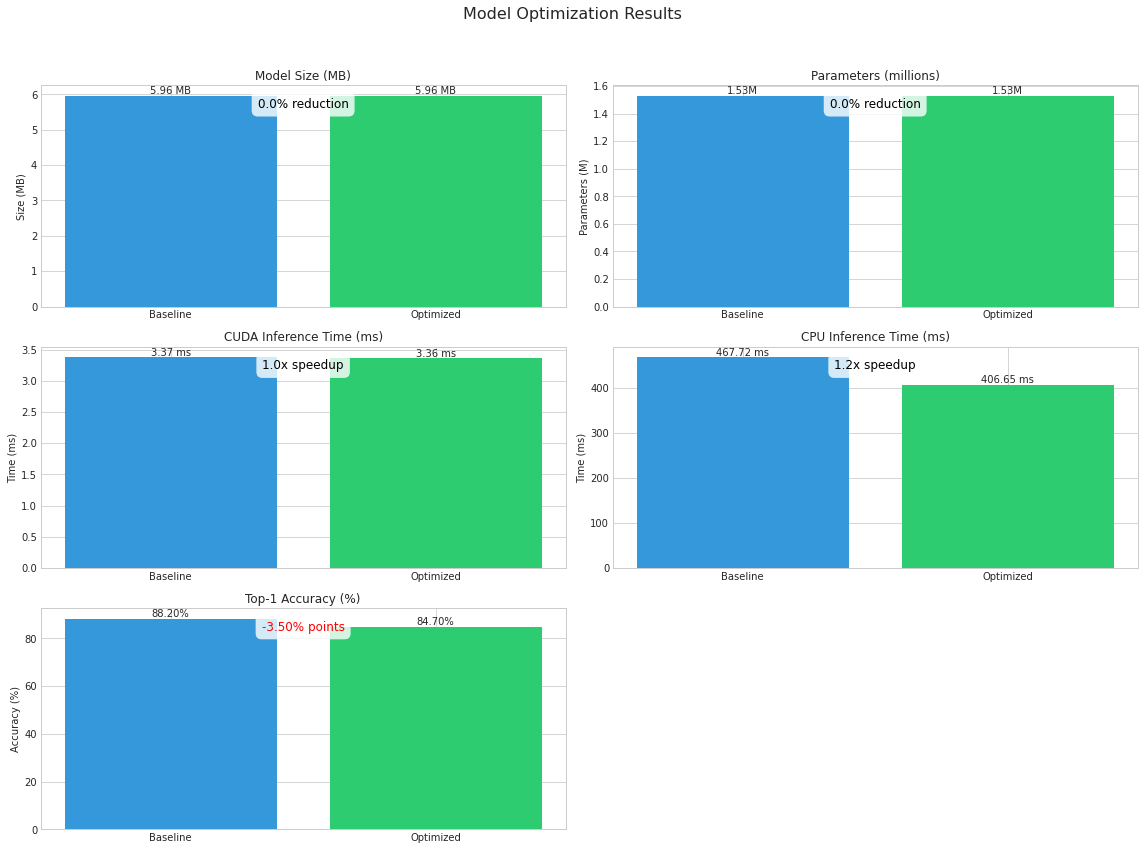


post_training/pruning/global_unstructured_0-4_cpu Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 406.65 ms (1.2x speedup)
CUDA Inference Time: 3.36 ms (1.0x speedup)
Accuracy: 84.70% (-3.50% change)
Requirements met: False


In [54]:
modules_to_prune = []
# Apply post-training pruning    
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## TODO: Experiment with different configurations
## We recommend testing pruning with various ratios
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
config = {
    'pruning_method': "global_unstructured",  # String
    'amount': 0.4,  # Float
    'modules_to_prune': modules_to_prune,  # (Optional) List
    'n': None,  # (Optional: Used for ln_structured pruning) Int
    'dim': None,  # Optional: Used for ln_structured pruning) Int
    'custom_pruning_fn': None,  # (Optional) Fn
    'device': torch.device('cpu'),  # Define with torch.device()
}

# Optimize and evaluate model
pruned_model, pruned_results, experiment_name = apply_post_training_pruning(config)

#### 4.4 In-training - Pruning

Gradual pruning progressively prunes weights during training, allowing the model to adapt to increasing sparsity.

In [55]:
# Define a function to apply pruning during training and evaluate results
def apply_in_training_pruning(model, config):
    """
    Apply gradual pruning during training.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    pruning_method, initial_sparsity, final_sparsity = config['pruning_method'], config['initial_sparsity'], config['final_sparsity'] 
    start_epoch, end_epoch = config['start_epoch'], config['end_epoch'] 
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/pruning/{pruning_method}_sparsity{initial_sparsity}-{final_sparsity}_epochs{start_epoch}-{end_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying gradual pruning from {initial_sparsity:.1%} to {final_sparsity:.1%} sparsity")
    
    # Move model to specified device
    model = model.to(device)
    
    # Train with gradual pruning
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    pruned_model, pruning_stats, pruned_best_accuracy, pruned_best_epoch = train_with_pruning(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(pruning_stats, f, indent=4)
    
    # Save the quantized model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=pruning_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    return pruned_model, comparison_results, experiment_name


In [56]:
# Apply in-training pruning 
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html
## Create a new model instance
model = MobileNetV3_Household()

## TODO: Experiment with different configurations
# We recommend testing pruning with various sparsity and epochs settings
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
config = {
    # General training config
    'num_epochs': None,  # Integer
    'criterion': None,  # A PyTorch loss  
    'optimizer': None,  # A PyTorch optimizer   
    'scheduler': None,  # A PyTorch scheduler
    'patience': None,  # Integer
    'device': None,  # Define with torch.device()
    'grad_clip_norm': None,  # Float
    # Pruning-specific config
    'initial_sparsity': None,  # Float
    'final_sparsity': None,    # Float
    'start_epoch': None,  # Integer
    'end_epoch': None,  # Integer  
    'pruning_frequency': None,  # Integer
    'pruning_method': None,  # String
    'schedule_type': None,  # String
    'only_prune_conv': None,  # Boolean
}
    
#pruned_model, pruned_comparison_results, experiment_name = apply_in_training_pruning(model, config)

#### 4.5 In-training - Knowledge Distillation

Knowledge distillation trains a smaller student model to mimic a larger teacher model.

In [57]:
%reload_ext autoreload
# Define a function to apply knowledge distillation and evaluate results
def apply_knowledge_distillation(teacher_model, student_model, config):
    """
    Apply knowledge distillation from a teacher model to a student model.
    
    Args:
        teacher_model: Pre-trained teacher model
        student_model: Smaller student model to train
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (distilled_student_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    temperature, alpha = config['temperature'], config['alpha']
    num_epochs = config['num_epochs']
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/distillation/temp{temperature}_alpha{alpha}_epochs{num_epochs}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying knowledge distillation with temperature={temperature} and alpha={alpha}")
    
    # Move models to specified device
    teacher_model = teacher_model.to(device)
    student_model = student_model.to(device)
    
    # Train student with knowledge distillation
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(distillation_stats, f, indent=4)
    
    # Save the distilled student model
    save_model(distilled_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate distilled student model
    metrics, confusion_matrix = evaluate_optimized_model(
        distilled_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=distillation_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        distilled_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return distilled_model, comparison_results, experiment_name


In [58]:
%reload_ext autoreload
import copy 
## Load the pre-trained teacher model
teacher_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth")
teacher_model.eval()  # Teacher should be in eval mode

## Create student model
## TODO: Check the model implementation in the `compression/` folder
student_model = MobileNetV3_Household_Small(num_classes=len(class_names), width_mult=1, linear_size=16, dropout=0.3) #, weights=None)
## Uncomment print below to inspect the student model architecture
#print_model_summary(student_model)
num_params = sum([p.numel() for p in student_model.parameters()])
num_params_b = sum([p.numel() for p in baseline_model.parameters()])
print(num_params, num_params_b)

936410 1528106


In [59]:
optimizer = torch.optim.AdamW(student_model.parameters(), lr=0.0004)#, weight_decay=1e-4)  # A PyTorch optimizer
print("Optimizer created")
criterion = nn.CrossEntropyLoss()
print("Cross entropy loss created")

Optimizer created
Cross entropy loss created


In [60]:
# Apply knowledge distillation
## Find more info at https://pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html

# TODO: EXPERIMENT WITH DIFFERENT TRAINING PARAMETERS
# We recommend testing distillation with different alpha and temperature
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
config = {
    'num_epochs': 20,  # Integer
    'criterion': criterion,  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': None,  # A PyTorch scheduler
    'alpha': 0.7,  # Float
    'temperature': 3,  # Float
    'patience': 20,  # Integer # we do not want to exit training loop prematurely
    'device':  torch.device('cuda'),  # Define with torch.device()
}

Applying knowledge distillation with temperature=3 and alpha=0.7
Student parameters: 936,410
Teacher parameters: 1,528,106
Training with knowledge distillation for 20 epochs
Temperature: 3, Alpha: 0.7


Epoch 1/20 [Test]: 100%|██████████| 8/8 [00:00<00:00, 29.34it/s, loss=8.86, acc=40.2]


Epoch 1/20 - Train Loss: 8.0445, Train Acc: 32.22%, Test Loss: 2.2154, Test Acc: 40.20%, LR: 0.000400, Time: 3.10s
New best student model! Saving... (40.20%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs20/model.pth


Epoch 2/20 [Test]: 100%|██████████| 8/8 [00:00<00:00, 30.31it/s, loss=5.22, acc=58.7]


Epoch 2/20 - Train Loss: 5.4881, Train Acc: 54.30%, Test Loss: 1.3057, Test Acc: 58.70%, LR: 0.000400, Time: 3.05s
New best student model! Saving... (58.70%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs20/model.pth


...

Epoch 20/20 - Train Loss: 1.5087, Train Acc: 91.24%, Test Loss: 0.5068, Test Acc: 86.00%, LR: 0.000400, Time: 3.08s
Distillation completed. Best student accuracy: 87.20%
Best student model saved as '../models/in_training/distillation/temp3_alpha0-7_epochs20/model.pth' at epoch 17
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs20/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 28.90it/s]


Baseline metrics saved at ../results/in_training/distillation/temp3_alpha0-7_epochs20/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:00<00:00, 29.27it/s]


Confusion matrix saved to ../results/in_training/distillation/temp3_alpha0-7_epochs20/confusion_matrix.png


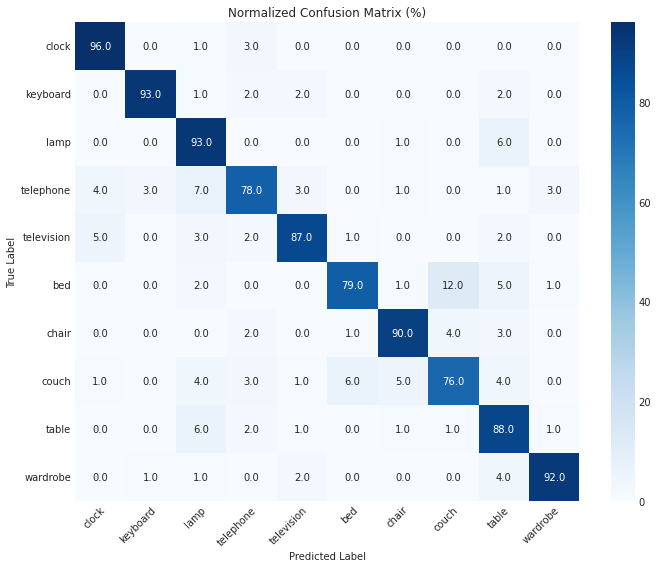

Weight distribution plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs20/weight_distribution.png


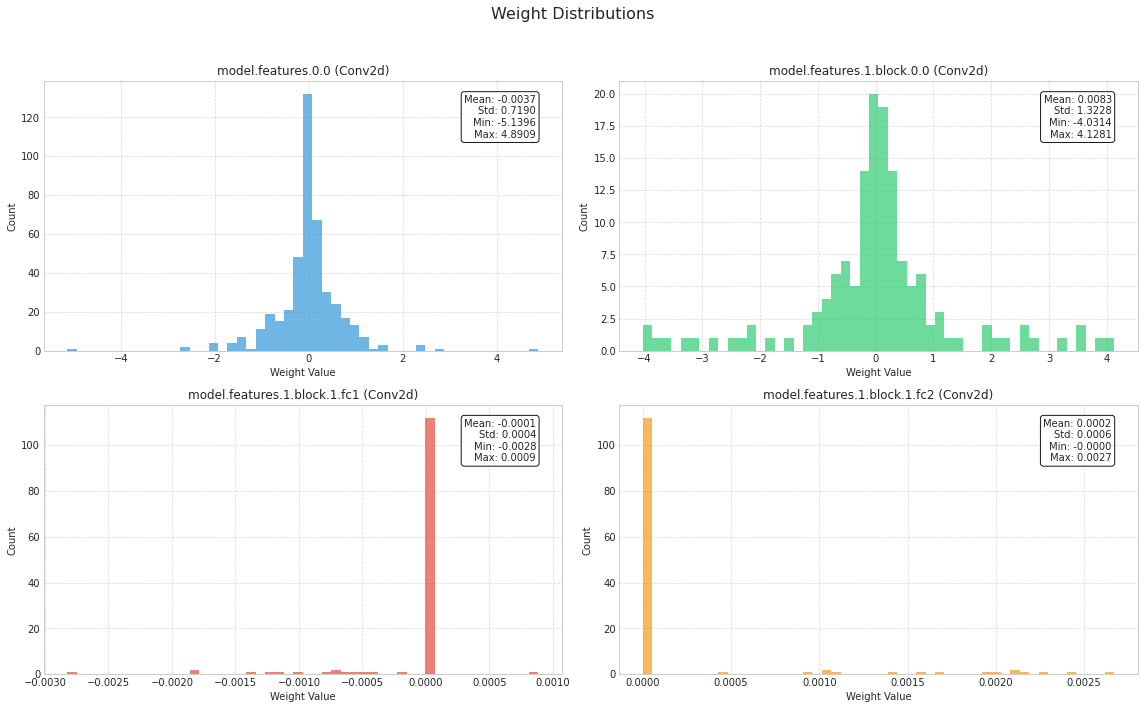

Training history plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs20/training_history.png


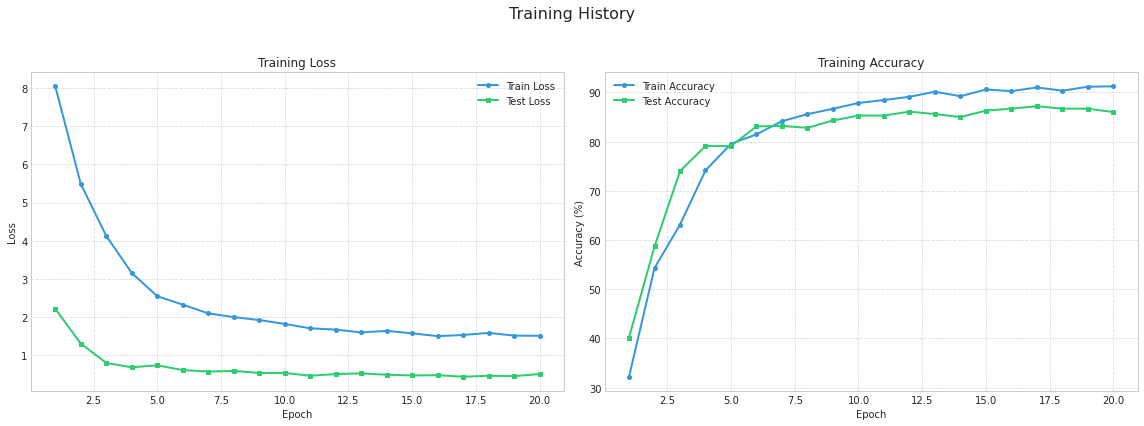


Optimized Model Metrics (in_training/distillation/temp3_alpha0-7_epochs20):
Accuracy: 87.20%
Model Size: 3.70 MB
CPU Inference Time: 497.53 ms (2.01 FPS)
CUDA Inference Time: 3.34 ms (299.62 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 29.10it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 29.67it/s]


Model comparison plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs20/comparison.png


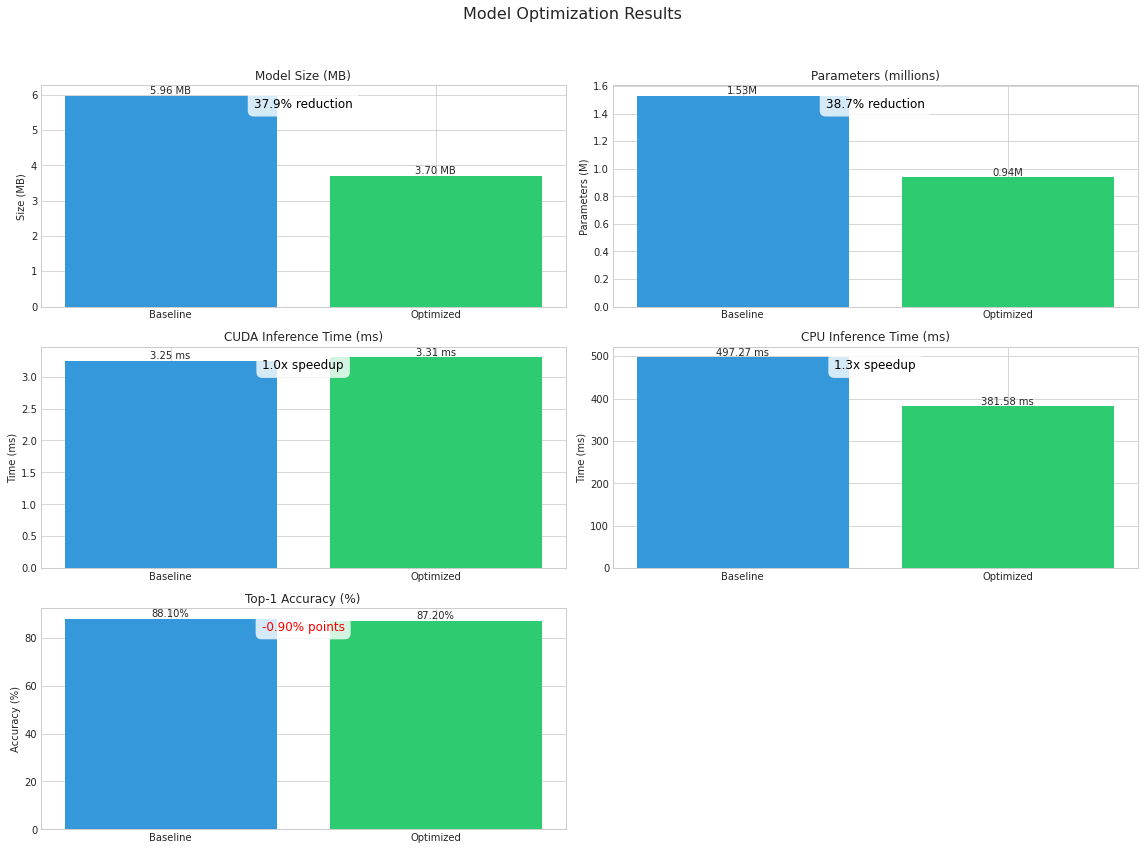


in_training/distillation/temp3_alpha0-7_epochs20 Results:
Model Size: 3.70 MB (37.9% reduction)
Parameters: 936,410 (38.7% reduction)
CPU Inference Time: 381.58 ms (1.3x speedup)
CUDA Inference Time: 3.31 ms (1.0x speedup)
Accuracy: 87.20% (-0.90% change)
Requirements met: False


In [61]:
%reload_ext autoreload
torch.cuda.empty_cache()
distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

In [62]:
distilled_model

MobileNetV3_Household_Small(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
     

#### 4.6 In-training - Graph Optimizations

Graph optimizations fuse operations and remove redundant nodes for better inference performance.

In [69]:
import copy
# Define a function to apply graph optimization and evaluate results
def apply_graph_optimization(optimization_method, input_shape=(1, 3, 32, 32), device=torch.device('cpu')):
    """
    Apply graph optimization to a model.
    
    Args:
        optimization_method: Optimization method to use in ["torchscript", "torch_fx"]
        input_shape: Shape of input tensor
        device: Which device to optimize the model on
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Check optimization method is supported
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/graph_optimization/{optimization_method}_{device}"

    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying optimization with {optimization_method} as method")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    
    # Apply graph optimization
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    optimized_model = optimize_model(
        orig_model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device,
    )
    
    # Save the optimized model
    file_extension = ".pth" if optimization_method=="torch_fx" else ".pt"
    save_model(optimized_model, f"../models/{experiment_name}/model{file_extension}")
    
    # Verify model equivalence
    is_equivalent = verify_model_equivalence(
        orig_model, 
        optimized_model, 
        input_shape=input_shape, 
        device=device
    )
 
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        optimized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        optimized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return optimized_model, comparison_results, experiment_name



In [70]:
input_size

(1, 3, 32, 32)

Applying optimization with torch_fx as method
Model saved to ../models/post_training/graph_optimization/torch_fx_cpu/model.pth
Original and optimized models produce equivalent outputs.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.87it/s]


Baseline metrics saved at ../results/post_training/graph_optimization/torch_fx_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.66it/s]


Confusion matrix saved to ../results/post_training/graph_optimization/torch_fx_cpu/confusion_matrix.png


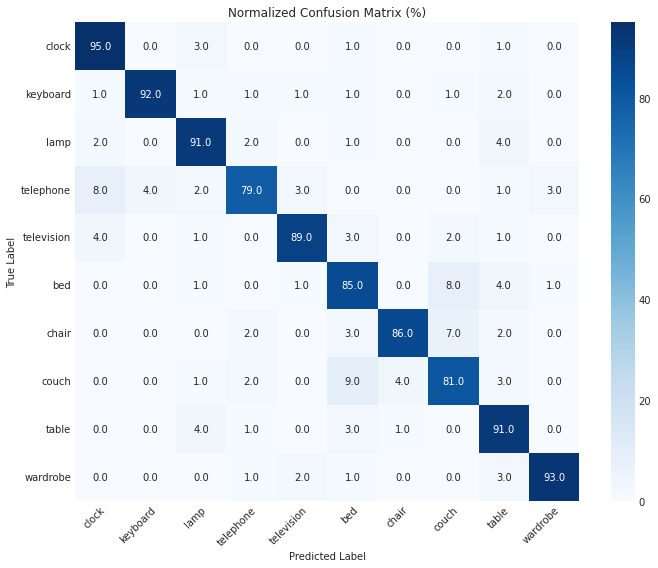


Optimized Model Metrics (post_training/graph_optimization/torch_fx_cpu):
Accuracy: 88.20%
Model Size: 5.85 MB
CPU Inference Time: 300.07 ms (3.33 FPS)
CUDA Inference Time: 2.64 ms (378.13 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.34it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.32it/s]


Model comparison plot saved to ../results/post_training/graph_optimization/torch_fx_cpu/comparison.png


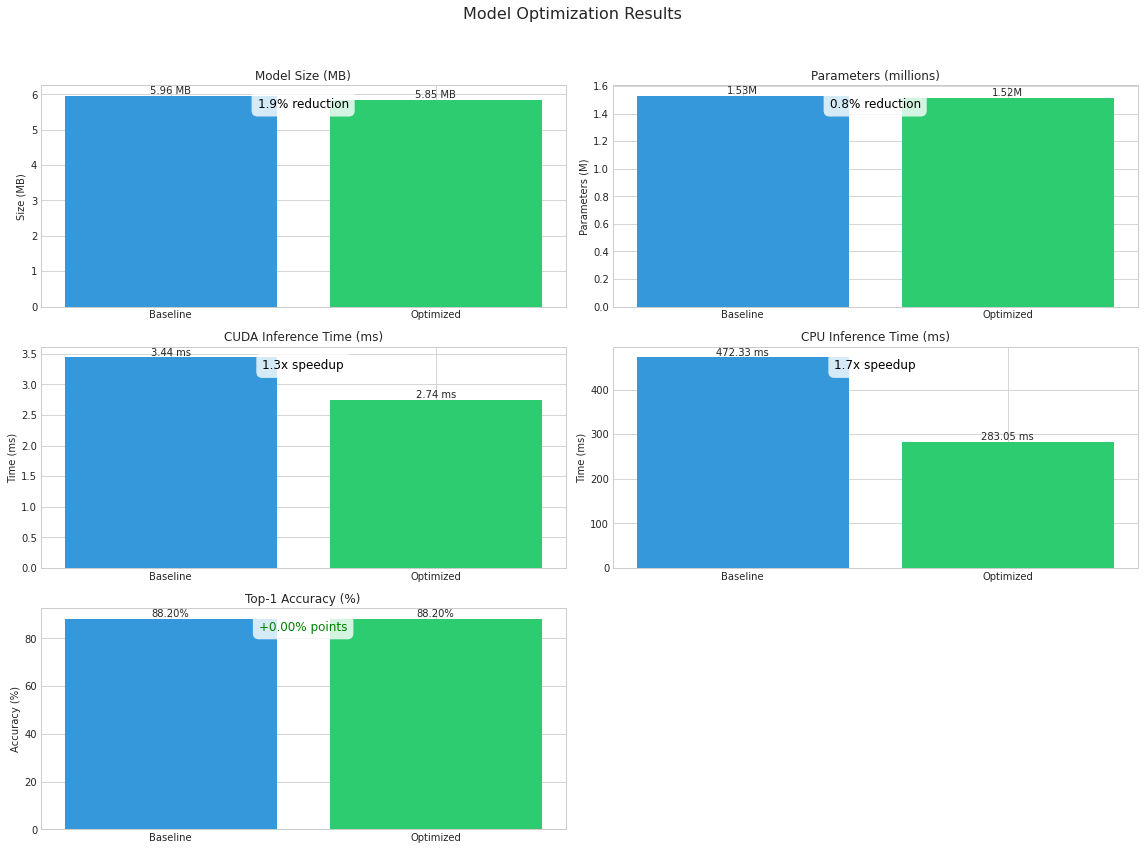


post_training/graph_optimization/torch_fx_cpu Results:
Model Size: 5.85 MB (1.9% reduction)
Parameters: 1,515,994 (0.8% reduction)
CPU Inference Time: 283.05 ms (1.7x speedup)
CUDA Inference Time: 2.74 ms (1.3x speedup)
Accuracy: 88.20% (+0.00% change)
Requirements met: False


In [71]:
# Apply graph optimization
## Find info at https://pytorch.org/docs/stable/fx.html and https://pytorch.org/docs/stable/jit.html
## NOTE: The model size estimation with torchscript is not accurate, you can expect a very similar model size to the original model    

## TODO: EXPERIMENT WITH DIFFERENT  PARAMETERS
## We recommend testing testing with both optimization methods and device types
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
optimization_method = "torch_fx"  # One of "torch_fx" or "torchscript"
device = torch.device('cpu')  # Define with torch.device()

# Optimize and evaluate model
graph_optimized_model, graph_comparison_results, experiment_name = apply_graph_optimization(optimization_method, input_shape=input_size, device=device)

## Step 5: Compare All Techniques

Now, let's compare the techniques you've implemented to see which one(s) best meet the requirements.

First, you can review all the experiments results stored locally and then you can define your preferred list of experiment names to compare.

In [72]:
# Check all experiments you've run to completion
list_experiments()

['baseline_mobilenet',
 'in_training/distillation/temp3_alpha0-7_epochs20',
 'in_training/quantization/epochs100_start1000',
 'in_training/quantization/epochs150_start1000',
 'in_training/quantization/epochs200_start',
 'in_training/quantization/epochs200_start1000',
 'post_training/graph_optimization/torch_fx_cpu',
 'post_training/pruning/global_unstructured_0-4_cpu',
 'post_training/quantization/dynamic']

In [73]:
# Define the list of experiments to compare
experiments_to_load_from_disk = list_experiments()
experiments_to_load_from_memory = None

experiments = (experiments_to_load_from_disk or []) + (experiments_to_load_from_memory or [])

In [74]:
# Or with a mix of pre-loaded and disk-based results
_ = compare_experiments(
    experiments=experiments,
    baseline_metrics=baseline_metrics
)


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,baseline_mobilenet,5.96,0.0%,447.70,1.0x,88.10,+0.0%,✗
1,in_training/distillation/temp3_alpha0-7_epochs20,3.70,37.9%,497.53,0.9x,87.20,-1.0%,✗
2,in_training/quantization/epochs100_start1000,1.58,73.5%,61.57,7.3x,79.80,-9.4%,✗
3,in_training/quantization/epochs150_start1000,1.58,73.5%,71.30,6.3x,83.30,-5.4%,✗
4,in_training/quantization/epochs200_start,1.58,73.5%,66.81,6.7x,88.10,+0.0%,✓
5,in_training/quantization/epochs200_start1000,1.58,73.5%,73.52,6.1x,88.60,+0.6%,✓
6,post_training/graph_optimization/torch_fx_cpu,5.85,1.9%,300.07,1.5x,88.20,+0.1%,✗
7,post_training/pruning/global_unstructured_0-4_cpu,5.96,0.1%,516.48,0.9x,84.70,-3.9%,✗
8,post_training/quantization/dynamic,4.24,28.8%,371.21,1.2x,88.10,+0.0%,✗


--------

**TODO: Analyze compression results and collect considerations on combining techniques for the multi-step pipeline**

After implementing and testing various compression techniques, analyze your experimental results to identify the most effective approaches for the UdaciSense application.

Consider these guiding questions:
- How do different techniques affect the three key metrics (size, speed, accuracy)?
- What technique-specific challenges or insights did you discover?
- Which techniques show complementary strengths and weaknesses?
- How could combining these techniques meet all CTO requirements?

Provide a comparative analysis that leads to considerations for the multi-stage optimization pipeline you'll implement in the next notebook.

## Compression Techniques Analysis for UdaciSense Object Recognition Model

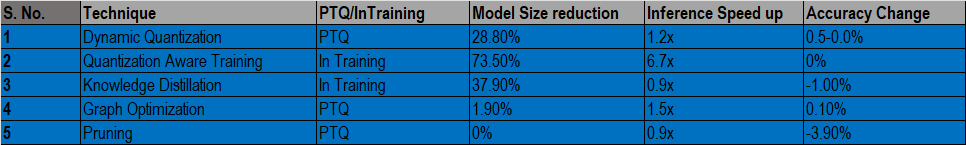

Please see the table above for general outcome of experiments done and its impact on model size, inference time and accuracy.

1) Dynamic Quantization is easiest to implement. General trends post implementation seen are - reduction in upto 30% in model size, inference speed up of 1.x+ with almost no change in accuracy level. This technique can also be used to quantize Linear layers. Conv2d is not supported.
2) Graph Optimization is also easy to implement. We used fx mechanism to fuse conv2d and batchnorm together and removal of dropout layer amongst other benefits that come with this technique. It always improves model size reduction and accuracy change by few fractions. It improves inference timings depending on the model being optimized. This technique can be used to piggy-back other techniques to improve the metrics and its pretty safe option to boost up numbers even though by small margin.
3) Pruning is easy to implement but it does not results in any change in model size, inference timings, however accuracy might go down depending on the quantum of pruning. Unless we remove pruned modules out which is quite a complex task, this technique is not suitable for our optimization project purpose.
4) Knowledge Distillation : This requires quite a bit of set up. I did not touch backbone. Reduced the intermediate size of classifier to 16 with minimal impact to accuracy post distillation process. Resizing backbone results in lower accuracy level and training becomes quite complex and may need multi-level training and still accuracy is not able to reach required level.
Our implementation reduced model size by 37.9% while keeping inference speed more or less same as original with minimal impact on accuracy. 
5) Quantization Aware Training: This technique is little tricky to implement. But when correctly done leads to huge improvement in model size reduction and inference timings without any impact to accuracy. Originally we started with Adam optimizer, however accuracy was taking a hit. Next I changed optimizer to SGD and implemented ReduceLRonPlateau learning rate scheduler along with few hacks in quantization process. This stabilized training process and we were able to reduce model size by 73.5%, achieving inference speed up of 6.7x while keep original baseline accuracy.

From the above discussion, we can draw following conclusions with respect to combining different techniques:
1) Dynamic Quantization can be used to augment distillation leading to further model size reduction and possible improvement in inference speed with minimal impact on accuracy
2) Graph Optimization can be used to augment any other technique mentioned above. This technique has shown upside potential in all the trial runs.

Feasible combination that can be tried are:
1) Quantization + graph optimization
2) Distillation + graph optimization
3) Distillation + quantization
4) Distillation + quantization + graph optimization
5) QAT + graph optimization

QAT is already meeting all CTO requirements and is a clear winner. Other combinations can be experimented with and have potential to meet CTO requirements.

> 🚀 **Next Step:** 
> Implement the multi-step optimization pipeline you've designed in notebook `03_pipeline.ipynb`  